In [1]:
import pyspark
from pyspark.sql import SparkSession

spark = (SparkSession.builder 
    .appName("EDA_DATE")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 3.5.0


In [2]:
from pyspark.sql import functions as F
import pandas as pd
pd.set_option('display.max_columns', None)
import plotly.express as px
import plotly.graph_objects as go
path = "/home/jovyan/work/data/bronze/"

In [3]:
!ls $path

complete_fraud_data_df.parquet


Análisis temporal del fraude

In [5]:
fraud_date_df = (
    spark.read.parquet(f"{path}complete_fraud_data_df.parquet")
    .withColumn("target", 
                F.when(F.col("target") == True, "Fraudulent")
                .when(F.col("target") == False, "Legitimate")
                .otherwise("Unlabeled") 
    )
    .select("date", "target", "client_id", "use_chip", "amount")
)
                               
Filas = fraud_date_df.count()
Columnas = len(fraud_date_df.columns)

print(f"Filas: {Filas}, Columnas: {Columnas}")
fraud_date_df.printSchema()
fraud_date_df.limit(5).toPandas()

Filas: 13305915, Columnas: 5
root
 |-- date: timestamp (nullable = true)
 |-- target: string (nullable = false)
 |-- client_id: string (nullable = true)
 |-- use_chip: string (nullable = true)
 |-- amount: double (nullable = true)



,date,target,client_id,use_chip,amount
0,2011-08-30 12:14:00,Legitimate,1703,Online Transaction,25.88
1,2011-08-30 12:18:00,Unlabeled,1621,Swipe Transaction,13.29
2,2011-08-30 12:19:00,Legitimate,1067,Swipe Transaction,10.60
3,2011-08-30 12:26:00,Legitimate,114,Swipe Transaction,46.21
4,2011-08-30 12:26:00,Legitimate,1145,Swipe Transaction,78.00


In [34]:
Filas = fraud_date_df.count()

fraud_perc = (
    fraud_date_df
    .groupBy("target")
    .agg(
        F.count("*").alias("Total"),
        ((F.count("*") / Filas) * 100).alias("Percentage")
    )
)

fraud_perc.show()

+----------+-------+------------------+
|    target|  Total|        Percentage|
+----------+-------+------------------+
| Unlabeled|4390952| 33.00000037577273|
|Fraudulent|  13332|0.1001960406330568|
|Legitimate|8901631|  66.8998035835942|
+----------+-------+------------------+



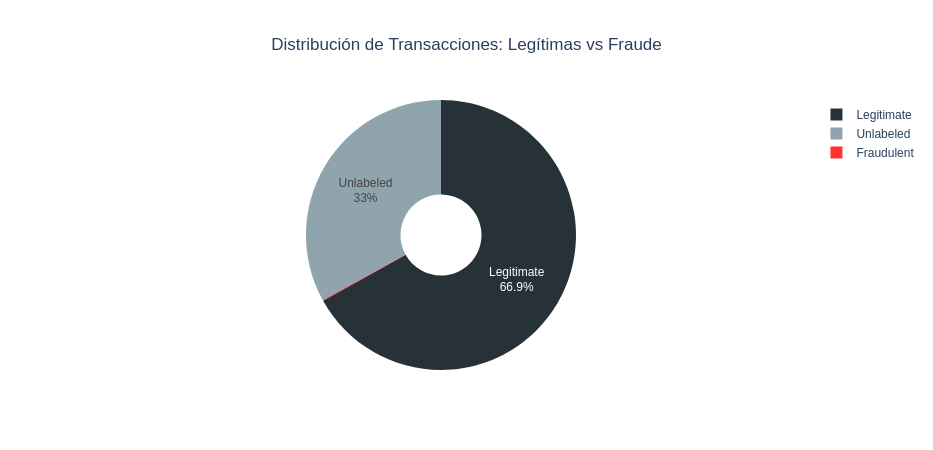

In [35]:
fraud_perc_pd = fraud_perc.toPandas()

fraud_perc_fig = px.pie(
    fraud_perc_pd ,
    values='Total', 
    names='target', 
    title= 'Distribución de Transacciones: Legítimas vs Fraude',
    color='target',
    color_discrete_map={'Legitimate': '#263238', 'Fraudulent': '#FF3333', 'Unlabeled': '#90A4AE'},
    hole=0.3
    )
fraud_perc_fig.update_traces(
    textposition='inside', 
    textinfo='percent+label',
    )date_fraud_unbiased_df
fraud_perc_fig.update_layout(width=650, height=450, title_x=0.5, autosize=False)

fraud_perc_fig.show()


In [36]:
val_min = fraud_date_df.agg(F.min("date")).collect()[0][0]
val_max = fraud_date_df.agg(F.max("date")).collect()[0][0]
print(F"Fecha mínima: {val_min}\nFecha máxima: {val_max}")

Fecha mínima: 2010-01-01 00:01:00
Fecha máxima: 2019-10-31 23:59:00


In [37]:
transactions_evolution_df = (
    fraud_date_df
    .withColumn("day", F.to_date(F.col("date")))
    .groupBy("day", "target") 
    .count()
    .orderBy("day")
)
transactions_evolution_df.show(10)

+----------+----------+-----+
|       day|    target|count|
+----------+----------+-----+
|2010-01-01|Legitimate| 2328|
|2010-01-01|Fraudulent|    1|
|2010-01-01| Unlabeled| 1134|
|2010-01-02|Legitimate| 1971|
|2010-01-02| Unlabeled| 1018|
|2010-01-03| Unlabeled| 1110|
|2010-01-03|Legitimate| 2200|
|2010-01-03|Fraudulent|    1|
|2010-01-04|Legitimate| 2214|
|2010-01-04|Fraudulent|    2|
+----------+----------+-----+
only showing top 10 rows



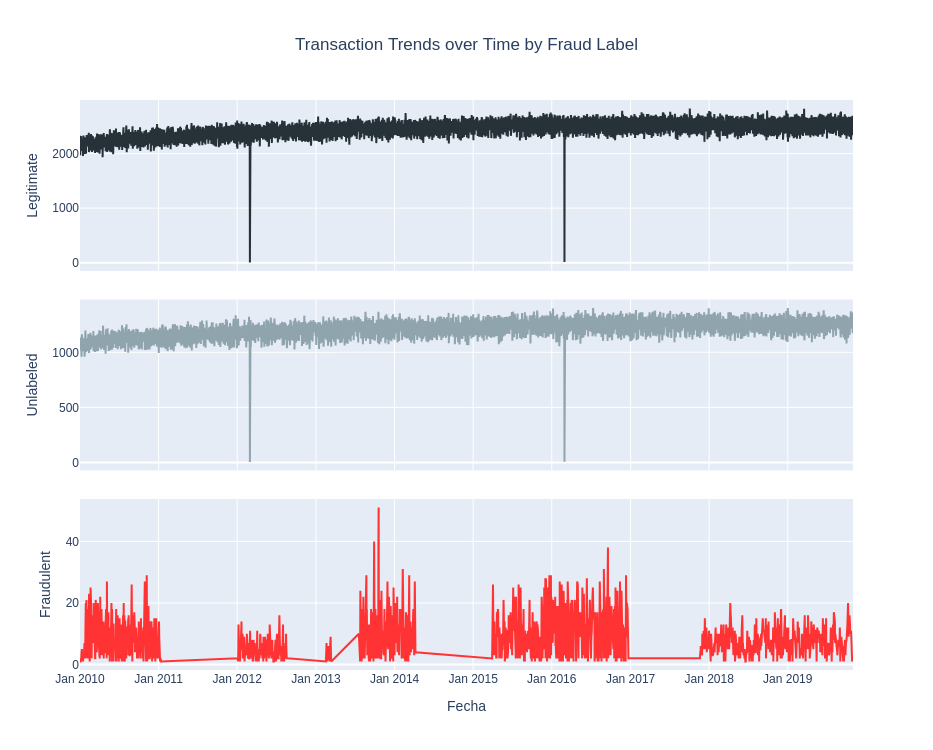

In [38]:
transactions_evolution_pd = transactions_evolution_df.toPandas()

transactions_evolution_false = transactions_evolution_pd[transactions_evolution_pd['target'] == 'Legitimate']
transactions_evolution_true = transactions_evolution_pd[transactions_evolution_pd['target'] == 'Fraudulent']
transactions_evolution_null = transactions_evolution_pd[transactions_evolution_pd['target'] == 'Unlabeled']

transactions_evolution_plot = go.Figure()

transactions_evolution_plot.add_trace(go.Scatter(
    x=transactions_evolution_false['day'], 
    y=transactions_evolution_false['count'], 
    name='Legitimate',
    line=dict(color='#263238', width=2),
    yaxis='y' 
))

transactions_evolution_plot.add_trace(go.Scatter(
    x=transactions_evolution_null['day'], 
    y=transactions_evolution_null['count'], 
    name='Unlabeled',
    line=dict(color='#90A4AE', width=2),
    yaxis='y2' 
))

transactions_evolution_plot.add_trace(go.Scatter(
    x=transactions_evolution_true['day'], 
    y=transactions_evolution_true['count'], 
    name='Fraudulent',
    line=dict(color='#FF3333', width=2),
    yaxis='y3' 
))

transactions_evolution_plot.update_layout(
    title_text='Transaction Trends over Time by Fraud Label',
    title_x=0.5,
    width=900,
    height=750,
    hovermode='x',
    legend_title_text='',
    showlegend=False,
    
    yaxis=dict(
        title= dict(text='Legitimate', standoff=10),
        domain=[0.7, 1.0],
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
    ),
    
    yaxis2=dict(
        title= dict(text='Unlabeled', standoff=10), 
        domain=[0.35, 0.65], 
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
    ),

    yaxis3=dict(
        title=dict(text='Fraudulent', standoff=10), 
        domain=[0.0, 0.30],
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
    ),
    
    xaxis=dict(
        title='Fecha',
        tickformat='%b %Y',
        hoverformat='%A, %d %b %Y',
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
        anchor='y3',      
        side='bottom' 
    )
)

transactions_evolution_plot.show()


Como observamos no tenemos registros de transacciones "Non-fraudulent" y "Unlabeled" en las fechas 29 de Febrero de 2012 y de 2016, ambos años bisiestos. Sin embargo si tenemos registros de fraudes cometidos. Para evitar un sesgo en los datos eliminaremos estas 2 fechas.
Además tenemos un sesgo en el registro de transacciones fraudulentas, por lo que filtraremos los datos para ese gap, además en 2012 y 2018 y 2019 se aprecia que el volumen de registros es inferior, esto también podría alterar el modelado, por eso seleccionaremos los siguientes rangos de fechas:
- 1 enero 2010 - 8 enero 2011  
- 19 julio 2013 - 8 abril 2014  
- 30 marzo 2015 - 22 diciembre 2016  

Además descartamos las transacciones unlabeled, ya que no nos aportaran informacion para la modelizacion


In [6]:
date_fraud_unbiased_df = (
    fraud_date_df
    .withColumn("day", F.to_date(F.col("date")))
    .filter(
        (F.col("day").between("2010-01-01", "2011-01-08")) |
        (F.col("day").between("2013-07-19", "2014-04-08")) |
        (F.col("day").between("2015-03-30", "2016-12-22"))
    )
    .filter(F.col("day") != "2016-02-29")
    .filter(F.col("target") != "Unlabeled")
    .withColumns({
        "hour": F.hour(F.col("date")),
        "minute": F.minute(F.col("date")),
        "time_str": F.date_format(F.col("date"), "HH:mm"),
        "minutes_of_day": (F.col("hour") * 60) + F.col("minute")
    })
    .select("target", "client_id", "day", "time_str", "minutes_of_day", "use_chip", "amount")
)

Filas_unbiased = date_fraud_unbiased_df.count()
Columnas_unbiased = len(date_fraud_unbiased_df.columns)

print(f"Filas: {Filas_unbiased}, Columnas: {Columnas_unbiased}")
date_fraud_unbiased_df.printSchema()
date_fraud_unbiased_df.limit(5).toPandas()

Filas: 3128626, Columnas: 7
root
 |-- target: string (nullable = false)
 |-- client_id: string (nullable = true)
 |-- day: date (nullable = true)
 |-- time_str: string (nullable = true)
 |-- minutes_of_day: integer (nullable = true)
 |-- use_chip: string (nullable = true)
 |-- amount: double (nullable = true)



,target,client_id,day,time_str,minutes_of_day,use_chip,amount
0,Legitimate,1684,2013-07-19,00:18,18,Online Transaction,20.24
1,Legitimate,246,2013-07-19,06:19,379,Swipe Transaction,3.99
2,Legitimate,150,2013-07-19,07:08,428,Swipe Transaction,3.60
3,Legitimate,1102,2013-07-19,07:11,431,Swipe Transaction,4.73
4,Legitimate,843,2013-07-19,07:16,436,Swipe Transaction,45.71


In [40]:
fraud_unbiased_perc = (
    date_fraud_unbiased_df
    .groupBy("target")
    .agg(
        F.count("*").alias("Total"),
        ((F.count("*") / Filas_unbiased) * 100).alias("Percentage")
    )
)

fraud_unbiased_perc.show()

+----------+-------+------------------+
|    target|  Total|        Percentage|
+----------+-------+------------------+
|Fraudulent|   9178|0.2933556136144109|
|Legitimate|3119448| 99.70664438638559|
+----------+-------+------------------+



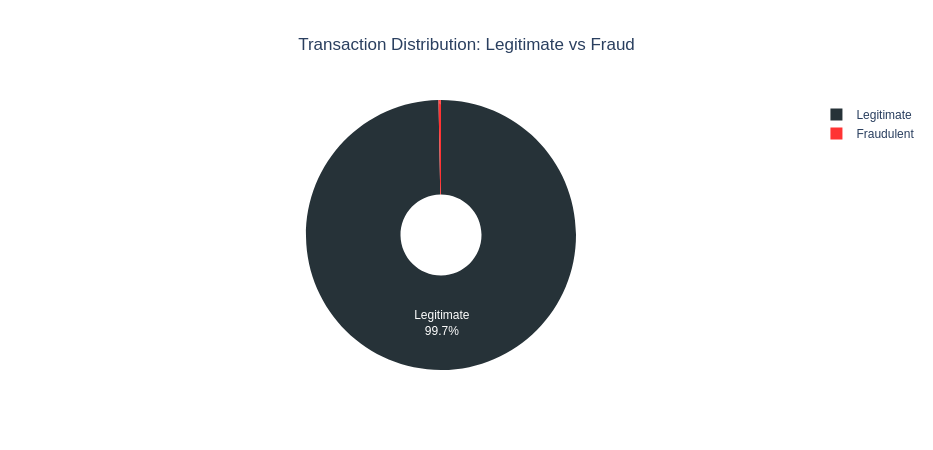

In [41]:
fraud_unbiased_perc_pd = fraud_unbiased_perc.toPandas()

fraud_unbiased_perc_fig = px.pie(
    fraud_unbiased_perc_pd ,
    values='Total', 
    names='target', 
    title= 'Transaction Distribution: Legitimate vs Fraud',
    color='target',
    color_discrete_map={'Legitimate': '#263238', 'Fraudulent': '#FF3333'},
    hole=0.3
    )

fraud_unbiased_perc_fig.update_traces(
    textposition='inside', 
    textinfo='percent+label',
    )
fraud_unbiased_perc_fig.update_layout(width=650, height=450, title_x=0.5, autosize=False)

fraud_unbiased_perc_fig.show()

In [44]:
transactions_evolution_unbiased_df = (
    date_fraud_unbiased_df
    .groupBy("day", "target") 
    .count()
    .orderBy("day")
)

transactions_evolution_unbiased_df.show(10)


+----------+----------+-----+
|       day|    target|count|
+----------+----------+-----+
|2010-01-01|Fraudulent|    1|
|2010-01-01|Legitimate| 2328|
|2010-01-02|Legitimate| 1971|
|2010-01-03|Legitimate| 2200|
|2010-01-03|Fraudulent|    1|
|2010-01-04|Legitimate| 2214|
|2010-01-04|Fraudulent|    2|
|2010-01-05|Fraudulent|    1|
|2010-01-05|Legitimate| 2268|
|2010-01-06|Legitimate| 2318|
+----------+----------+-----+
only showing top 10 rows



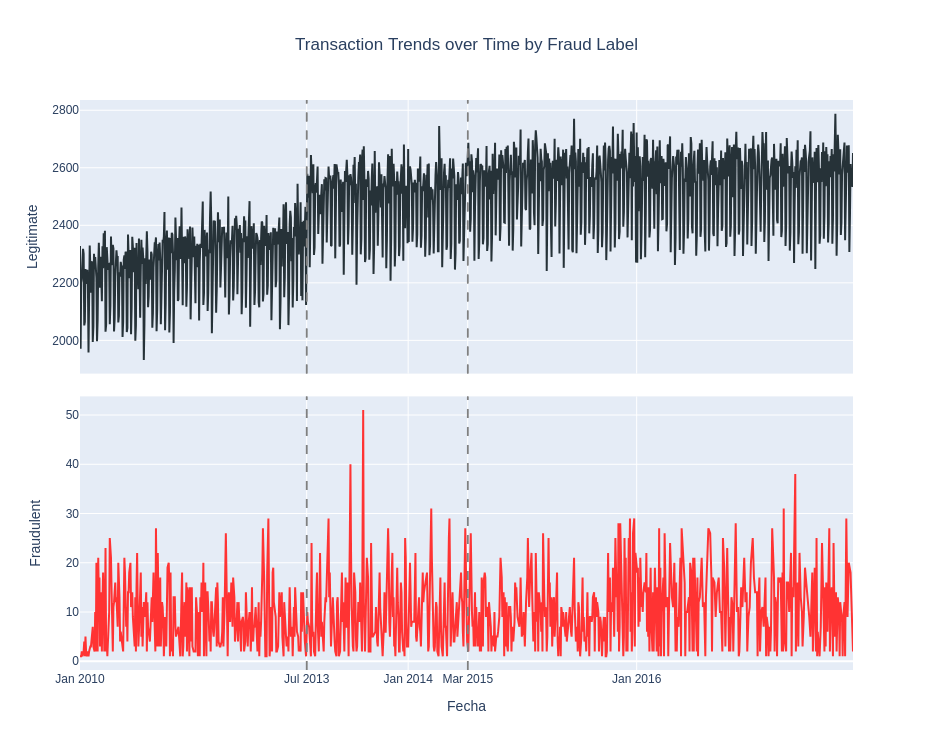

In [45]:
transactions_evolution_unbiased_pd = transactions_evolution_unbiased_df.toPandas()

transactions_evolution_unbiased_false = transactions_evolution_unbiased_pd[
    transactions_evolution_unbiased_pd['target'] == 'Legitimate']
transactions_evolution_unbiased_true = transactions_evolution_unbiased_pd[
    transactions_evolution_unbiased_pd['target'] == 'Fraudulent']

transactions_evolution_unbiased_plot = go.Figure()

transactions_evolution_unbiased_plot.add_trace(go.Scatter(
    x=transactions_evolution_unbiased_false['day'], 
    y=transactions_evolution_unbiased_false['count'], 
    name='Legitimate',
    line=dict(color='#263238', width=2),
    xaxis='x',
    yaxis='y' 
))

transactions_evolution_unbiased_plot.add_trace(go.Scatter(
    x=transactions_evolution_unbiased_true['day'], 
    y=transactions_evolution_unbiased_true['count'], 
    name='Fraudulent',
    line=dict(color='#FF3333', width=2),
    xaxis='x',
    yaxis='y2' 
))

transactions_evolution_unbiased_plot.update_layout(
    title_text='Transaction Trends over Time by Fraud Label', title_x=0.5,
    width=900, height=750, autosize=False,
    hovermode='x',
    legend_title_text='', showlegend=False,
    
    yaxis=dict(
        title= dict(text='Legitimate', standoff=10),
        domain=[0.52, 1.0],
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
    ),
    
    yaxis2=dict(
        title= dict(text='Fraudulent', standoff=20),
        domain=[0.0, 0.48],
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
    ),
    
    xaxis=dict(
        title='Fecha',
        type='date', tickformat='%b %Y', hoverformat='%A, %d %b %Y',
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
        anchor='y2', side='bottom',
        rangebreaks=[
            dict(bounds=["2011-01-09", "2013-07-18"]), 
            dict(bounds=["2014-04-09", "2015-03-29"])
        ] 
    )
)

for fecha in ["2011-01-09", "2013-07-18", "2014-04-09", "2015-03-29"]:
    transactions_evolution_unbiased_plot.add_shape(
        type="line", xref="x", yref="paper",
        x0=fecha, x1=fecha, y0=0.52, y1=1.0,
        line=dict(color="gray", width=1.5, dash="dash")
)

for fecha in ["2011-01-09", "2013-07-18", "2014-04-09", "2015-03-29"]:
    transactions_evolution_unbiased_plot.add_shape(
        type="line", xref="x", yref="paper",
        x0=fecha, x1=fecha, y0=0.0, y1=0.48,
        line=dict(color="gray", width=1.5, dash="dash")
)



transactions_evolution_unbiased_plot.show()

In [46]:
monthly_unbiased_df = (
    transactions_evolution_unbiased_df
    .withColumn("month_num", F.month(F.col("day")))
    .withColumn("month_name", F.date_format(F.col("day"), "MMMM"))
    .groupBy("month_num", "month_name", "target")
    .agg(F.avg("count").alias("Average_Transactions"))
    .orderBy("month_num", "target")
)

monthly_unbiased_df.show(10)


+---------+----------+----------+--------------------+
|month_num|month_name|    target|Average_Transactions|
+---------+----------+----------+--------------------+
|        1|   January|Fraudulent|                8.56|
|        1|   January|Legitimate|   2406.366336633663|
|        2|  February|Fraudulent|  10.285714285714286|
|        2|  February|Legitimate|  2426.9166666666665|
|        3|     March|Fraudulent|           11.296875|
|        3|     March|Legitimate|  2427.2105263157896|
|        4|     April|Fraudulent|  10.013513513513514|
|        4|     April|Legitimate|   2428.316326530612|
|        5|       May|Fraudulent|  10.393939393939394|
|        5|       May|Legitimate|   2444.989247311828|
+---------+----------+----------+--------------------+
only showing top 10 rows



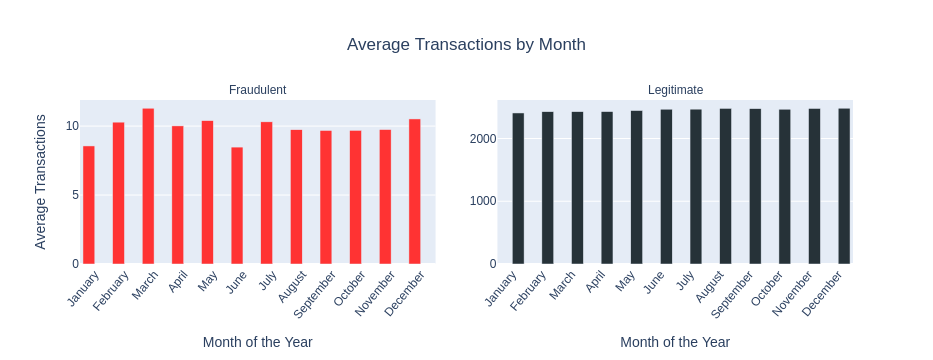

In [47]:
monthly_unbiased_pd = monthly_unbiased_df.toPandas()

monthly_unbiased_plot = px.bar(
    monthly_unbiased_pd,
    x="month_name",                  
    y="Average_Transactions",        
    color="target",
    facet_col="target",             
    facet_col_spacing=0.08,       
    barmode="group",
    title="Average Transactions by Month",
    labels={
        "month_name": "Month of the Year", 
        "Average_Transactions": "Average Transactions",
        "target": ""
    },
    color_discrete_map={'Legitimate': "#263238", 'Fraudulent': "#FF3333"} 
)

monthly_unbiased_plot.update_traces(
    hovertemplate="Avg: %{y:,.2f}<extra></extra>"
)

monthly_unbiased_plot.update_yaxes(matches=None, showticklabels=True)
monthly_unbiased_plot.update_xaxes(showticklabels=True, tickangle=-50) 

monthly_unbiased_plot.update_layout(
    title_x=0.5, hovermode="closest", 
    showlegend=False
)

monthly_unbiased_plot.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

monthly_unbiased_plot.show()


In [48]:
weekday_unbiased_df = (
    transactions_evolution_unbiased_df
    .withColumn("weekday_num", F.dayofweek(F.col("day")))
    .withColumn("weekday_name", F.date_format(F.col("day"), "EEEE"))
    .groupBy("weekday_num", "weekday_name", "target")
    .agg(F.avg("count").alias("Avg"))
    .orderBy("weekday_num")
)

weekday_unbiased_df.show(10)

+-----------+------------+----------+------------------+
|weekday_num|weekday_name|    target|               Avg|
+-----------+------------+----------+------------------+
|          1|      Sunday|Legitimate| 2520.508287292818|
|          1|      Sunday|Fraudulent|             13.55|
|          2|      Monday|Fraudulent| 8.506493506493506|
|          2|      Monday|Legitimate| 2519.414364640884|
|          3|     Tuesday|Legitimate|2480.6263736263736|
|          3|     Tuesday|Fraudulent|  9.20754716981132|
|          4|   Wednesday|Fraudulent| 5.448275862068965|
|          4|   Wednesday|Legitimate|2482.6629834254145|
|          5|    Thursday|Legitimate| 2463.022099447514|
|          5|    Thursday|Fraudulent|  9.30952380952381|
+-----------+------------+----------+------------------+
only showing top 10 rows



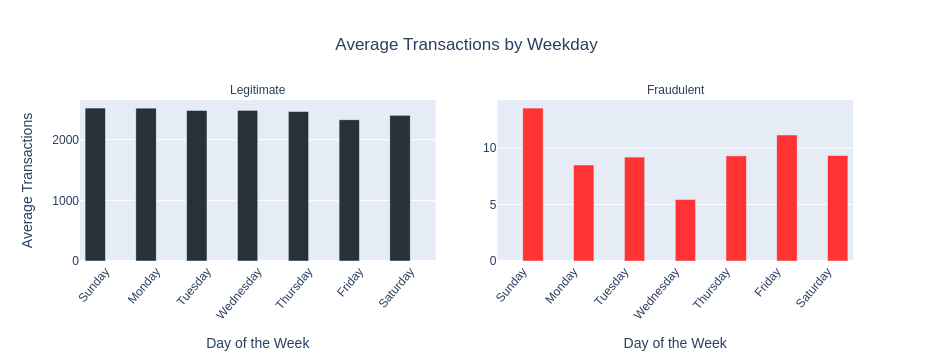

In [49]:
weekday_unbiased_pd = weekday_unbiased_df.toPandas()

weekday_unbiased_plot = px.bar(
    weekday_unbiased_pd,
    x="weekday_name",
    y="Avg",
    color="target",
    facet_col="target",
    facet_col_spacing=0.08,
    barmode="group",
    title="Average Transactions by Weekday",
    labels={"weekday_name": "Day of the Week", "Avg": "Average Transactions","target": ""},
    color_discrete_map={'Legitimate': "#263238", 'Fraudulent': "#FF3333"} 
)

weekday_unbiased_plot.update_traces(
    hovertemplate="Avg: %{y:,.2f}<extra></extra>"
)

weekday_unbiased_plot.update_yaxes(matches=None, showticklabels=True)
weekday_unbiased_plot.update_xaxes(showticklabels=True, tickangle=-50) 

weekday_unbiased_plot.update_layout(
    title_x=0.5,
    hovermode="closest",
    showlegend=False
)

weekday_unbiased_plot.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

weekday_unbiased_plot.show()


In [50]:
monthday_unbiased_df = (
    transactions_evolution_unbiased_df
    .withColumn("day_of_month", F.dayofmonth(F.col("day")))
    .groupBy("day_of_month", "target")
    .agg(F.avg("count").alias("Average_Transactions"))
    .orderBy("day_of_month")
)

monthday_unbiased_df.show(10)

+------------+----------+--------------------+
|day_of_month|    target|Average_Transactions|
+------------+----------+--------------------+
|           1|Fraudulent|   8.764705882352942|
|           1|Legitimate|  2486.0697674418607|
|           2|Legitimate|   2440.093023255814|
|           2|Fraudulent|   8.870967741935484|
|           3|Legitimate|   2434.279069767442|
|           3|Fraudulent|   8.515151515151516|
|           4|Fraudulent|   9.689655172413794|
|           4|Legitimate|  2463.5116279069766|
|           5|Legitimate|  2452.4651162790697|
|           5|Fraudulent|  10.575757575757576|
+------------+----------+--------------------+
only showing top 10 rows



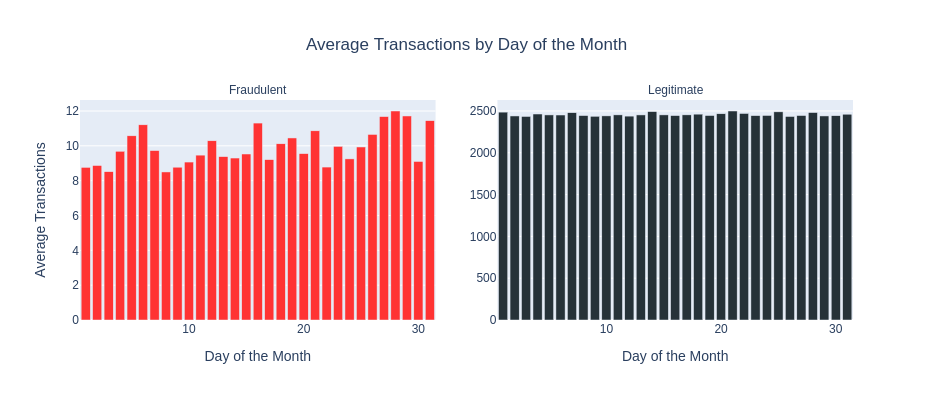

In [51]:
monthday_unbiased_pd = monthday_unbiased_df.toPandas()

month_day_plot = px.bar(
    monthday_unbiased_pd,
    x="day_of_month",
    y="Average_Transactions",
    color="target",
    facet_col="target",      
    facet_col_spacing=0.08,  
    title="Average Transactions by Day of the Month",
    labels={
        "day_of_month": "Day of the Month", 
        "Average_Transactions": "Average Transactions", 
        "target": ""
    },
    color_discrete_map={'Legitimate': "#263238", 'Fraudulent': "#FF3333"}
)

month_day_plot.update_traces(
    hovertemplate="Average: %{y:,.2f}<extra></extra>"
)

month_day_plot.update_yaxes(matches=None, showticklabels=True)
month_day_plot.update_xaxes(showticklabels=True)

month_day_plot.update_layout(
    title_x=0.5,
    height=400, autosize=False,
    hovermode="x unified",
    showlegend=False

)

month_day_plot.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

month_day_plot.show()


In [52]:
detailed_calendar_unbiased_df = (
    transactions_evolution_unbiased_df
    .withColumn("day_of_month", F.dayofmonth(F.col("day")))
    .withColumn("day_of_week", F.dayofweek(F.col("day")))
    .withColumn("weekday_name", F.date_format(F.col("day"), "EEEE"))
    .groupBy("day_of_month", "day_of_week", "weekday_name", "target")
    .agg(F.avg("count").alias("Avg"))
    .orderBy("day_of_month", "day_of_week")
)

print((detailed_calendar_unbiased_df.count(), len(detailed_calendar_unbiased_df.columns)))
detailed_calendar_unbiased_df.show(20)


(434, 5)
+------------+-----------+------------+----------+------------------+
|day_of_month|day_of_week|weekday_name|    target|               Avg|
+------------+-----------+------------+----------+------------------+
|           1|          1|      Sunday|Legitimate|            2512.8|
|           1|          1|      Sunday|Fraudulent|              10.8|
|           1|          2|      Monday|Fraudulent|               8.4|
|           1|          2|      Monday|Legitimate|2493.1666666666665|
|           1|          3|     Tuesday|Legitimate| 2553.285714285714|
|           1|          3|     Tuesday|Fraudulent| 9.333333333333334|
|           1|          4|   Wednesday|Legitimate|            2531.5|
|           1|          4|   Wednesday|Fraudulent|               4.0|
|           1|          5|    Thursday|Fraudulent|               7.0|
|           1|          5|    Thursday|Legitimate|2492.1666666666665|
|           1|          6|      Friday|Fraudulent|              10.4|
|          

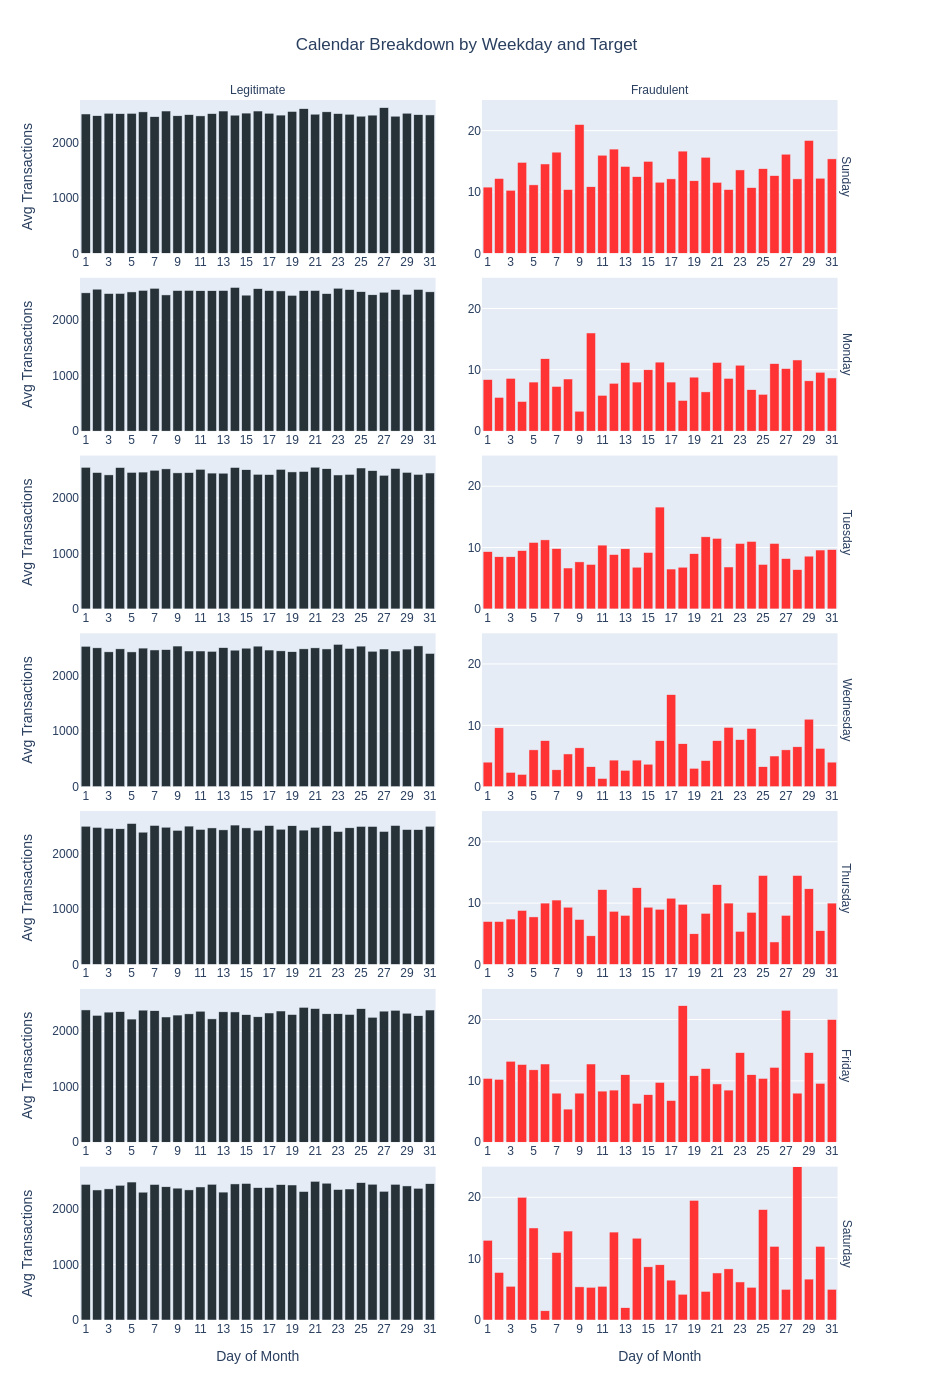

In [53]:
detailed_calendar_unbiased_pd = detailed_calendar_unbiased_df.toPandas()

detailed_calendar_unbiased_pd["day_of_month"] = detailed_calendar_unbiased_pd["day_of_month"].astype(str)

fig_calendar = px.bar(
    detailed_calendar_unbiased_pd,
    x="day_of_month",          
    y="Avg",
    color="target",
    facet_col="target",         
    facet_row="weekday_name",   
    facet_row_spacing=0.02,
    facet_col_spacing=0.06,     
    title="Calendar Breakdown by Weekday and Target",
    labels={"day_of_month": "Day of Month", "Avg": "Avg Transactions", "target": "Is Fraud?"},
    color_discrete_map={'Legitimate': "#263238", 'Fraudulent': "#FF3333"}
)

fig_calendar.update_yaxes(matches="y", showticklabels=True, col=1)
fig_calendar.update_yaxes(matches="y2", showticklabels=True, col=2, range=[0.0, 25])

fig_calendar.update_xaxes(showticklabels=True) 

fig_calendar.update_traces(hovertemplate="Day:%{x}<br>Avg: %{y:,.2f}<extra></extra>")

fig_calendar.update_layout(
    title_x=0.5, height=1400, date_fraud_unbiased_df
    hovermode="closest", showlegend=False
)

fig_calendar.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

fig_calendar.show()


In [56]:
time_fraud_unbiased_df = (
    date_fraud_unbiased_df
    .groupBy("minutes_of_day", "time_str", "target")
    .count()
    .orderBy("minutes_of_day")
)

time_fraud_unbiased_df.show(10)

+--------------+--------+----------+-----+
|minutes_of_day|time_str|    target|count|
+--------------+--------+----------+-----+
|             0|   00:00|Legitimate|  551|
|             1|   00:01|Legitimate|  510|
|             1|   00:01|Fraudulent|    1|
|             2|   00:02|Legitimate|  510|
|             3|   00:03|Legitimate|  482|
|             4|   00:04|Legitimate|  486|
|             5|   00:05|Legitimate|  506|
|             6|   00:06|Legitimate|  510|
|             7|   00:07|Legitimate|  495|
|             7|   00:07|Fraudulent|    1|
+--------------+--------+----------+-----+
only showing top 10 rows



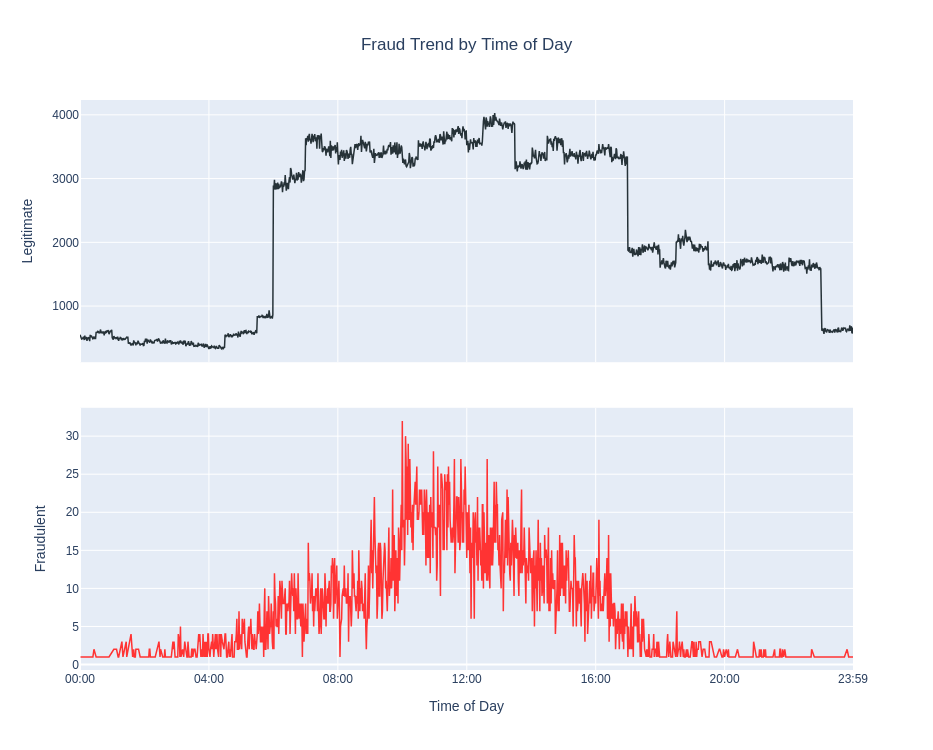

In [57]:
time_fraud_pd = time_fraud_unbiased_df.toPandas()

time_fraud_false = time_fraud_pd[time_fraud_pd['target'] == 'Legitimate']
time_fraud_true = time_fraud_pd[time_fraud_pd['target'] == 'Fraudulent']

time_evolution_plot = go.Figure()

time_evolution_plot.add_trace(go.Scatter(
    x=time_fraud_false['minutes_of_day'],
    y=time_fraud_false['count'], 
    name='Legitimate',
    mode='lines',
    line=dict(color='#263238', width=1.5),
    xaxis='x', yaxis='y',
    customdata=time_fraud_false['time_str'],
    hovertemplate="Time: %{customdata}<br>Count: %{y:,.0f}<extra></extra>"
))

time_evolution_plot.add_trace(go.Scatter(
    x=time_fraud_true['minutes_of_day'],
    y=time_fraud_true['count'], 
    name='Fraudulent',
    mode='lines',
    line=dict(color='#FF3333', width=1.5),
    xaxis='x', yaxis='y2',
    customdata=time_fraud_true['time_str'],
    hovertemplate="Time: %{customdata}<br>Count: %{y:,.0f}<extra></extra>"
))

time_evolution_plot.update_layout(
    title_text='Fraud Trend by Time of Day',
    title_x=0.5,
    width=950, height=750,
    hovermode='closest',
    showlegend=False,
    
    yaxis=dict(
        title=dict(text='Legitimate'), 
        domain=[0.54, 1.0], 
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"),
    yaxis2=dict(
        title=dict(text='Fraudulent'), 
        domain=[0.0, 0.46],
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"),
    
    xaxis=dict(
        title='Time of Day',
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
        anchor='y2', side='bottom',
        tickmode="array",
        tickvals=[0, 240, 480, 720, 960, 1200, 1439],
        ticktext=["00:00", "04:00", "08:00", "12:00", "16:00", "20:00", "23:59"]
    )
)

time_evolution_plot.show()


In [28]:
date_fraud_unbiased_df.show(10)

+-------------------+----------+---------+
|               date|    target|client_id|
+-------------------+----------+---------+
|2013-07-19 00:18:00|Legitimate|     1684|
|2013-07-19 06:19:00|Legitimate|      246|
|2013-07-19 07:08:00|Legitimate|      150|
|2013-07-19 07:11:00|Legitimate|     1102|
|2013-07-19 07:16:00|Legitimate|      843|
|2013-07-19 07:18:00|Legitimate|     1020|
|2013-07-19 07:26:00|Legitimate|     1810|
|2013-07-19 07:42:00|Legitimate|     1755|
|2013-07-19 07:46:00|Legitimate|     1166|
|2013-07-19 08:01:00|Legitimate|     1041|
+-------------------+----------+---------+
only showing top 10 rows



Analizamos el historial de transacciones de algunos clientes, en esta sección y en las siguientes tendremos en cuenta el tipo de transacción según el método de pago

In [8]:
fraudulent_client_df = (
    date_fraud_unbiased_df
    .select("client_id", "target")
    .filter(F.col("target") == 'Fraudulent')
    .distinct()
    .collect()
)

fraudulent_client_list = [row["client_id"] for row in fraudulent_client_df]
print("Total de clientes con operaciones fraudulentas:", len(fraudulent_client_list))

Total de clientes con operaciones fraudulentas: 1045


In [19]:
client_df = (
    date_fraud_unbiased_df
    .filter(F.col("client_id").isin(fraudulent_client_list))
    .select("client_id", "day", "time_str", "minutes_of_day", "use_chip", "target", "amount")
)

Filas_client = client_df.count()
Columnas_client = len(client_df.columns)

print(f"Filas: {Filas_client}, Columnas: {Columnas_client}")
client_df.printSchema()
client_df.limit(5).toPandas()

Filas: 2728092, Columnas: 7
root
 |-- client_id: string (nullable = true)
 |-- day: date (nullable = true)
 |-- time_str: string (nullable = true)
 |-- minutes_of_day: integer (nullable = true)
 |-- use_chip: string (nullable = true)
 |-- target: string (nullable = false)
 |-- amount: double (nullable = true)



,client_id,day,time_str,minutes_of_day,use_chip,target,amount
0,1684,2013-07-19,00:18,18,Online Transaction,Legitimate,20.24
1,246,2013-07-19,06:19,379,Swipe Transaction,Legitimate,3.99
2,150,2013-07-19,07:08,428,Swipe Transaction,Legitimate,3.60
3,1102,2013-07-19,07:11,431,Swipe Transaction,Legitimate,4.73
4,843,2013-07-19,07:16,436,Swipe Transaction,Legitimate,45.71


In [47]:
def plot_client_behaviour_time(client_ID):
    client_transaction_df = client_df.filter(F.col("client_id").isin(client_ID))
    client_transaction_pd = client_transaction_df.toPandas()
    client_transaction_pd['day_dt'] = pd.to_datetime(client_transaction_pd['day'])
    client_transaction_pd['hover_date_str'] = client_transaction_pd['day_dt'].dt.strftime("%A, %d %b %Y")
    client_transaction_pd['amount_absolute'] = client_transaction_pd['amount'].abs()
    client_transaction_pd['amount_sign'] = client_transaction_pd['amount'].apply(
        lambda x: 'Positive' if x >= 0 else 'Negative')    
    ordered_days = sorted(client_transaction_pd['day'].astype(str).unique())
    
    client_transaction_fig = px.scatter(
        client_transaction_pd,
        x="day",        
        y="minutes_of_day",
        size="amount_absolute",
        symbol="amount_sign",     
        symbol_sequence=['circle', 'x'],
        color="target",
        facet_row="use_chip",         
        facet_row_spacing=0.08,       
        height=750, width=850,                
        opacity=0.6,
        category_orders={"target": ["Legitimate", "Fraudulent"]},
        custom_data=["hover_date_str", "use_chip", "time_str", "amount"],
        title= f"<b>Transactions Behaviour, ClientID: {client_ID}</b>",
        labels={"day": "Date", "minutes_of_day": "Time"}
    )
    
    client_transaction_fig.update_traces(
        marker=dict(line=dict(color='black', width=0.45)),
        hovertemplate="<b>%{customdata[0]}</b><br>Chip: %{customdata[1]}\
        <br>time: %{customdata[2]}<br>amount: %{customdata[3]}<extra></extra>"
    )
    
    client_transaction_fig.update_layout(
        plot_bgcolor="#F5F5F5", paper_bgcolor="white", autosize=False,
        legend=dict(title="", orientation="h", yanchor="top", y=1.08, xanchor="left", x=0.65)
    )
    
    client_transaction_fig.update_xaxes(
        showticklabels=True, tickformat="%A, %d %b %Y", matches="x", tickangle=-45, nticks=12,
        type='category', categoryorder='array', categoryarray=ordered_days,
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
    
    ) 
    
    client_transaction_fig.update_xaxes(showticklabels=False, row=2)
    client_transaction_fig.update_xaxes(showticklabels=False, row=3)
    
    client_transaction_fig.update_yaxes(
        showgrid=True, gridcolor="#EAEAEA",
        tickvals=[0, 240, 480, 720, 960, 1200, 1439],
        ticktext=["00:00", "04:00", "08:00", "12:00", "16:00", "20:00", "23:59"]
    )
    
    client_transaction_fig.for_each_annotation(lambda a: a.update(
        text=f"<b>{a.text.split('=')[-1]}</b>",
        font=dict(size=14, color="black")
        )
    )
    
    client_transaction_fig.add_vline(x="2011-01-08", line_width=1.5, line_dash="dash")
    client_transaction_fig.add_vline(x="2015-03-30", line_width=1.5, line_dash="dash")
    
    return client_transaction_fig

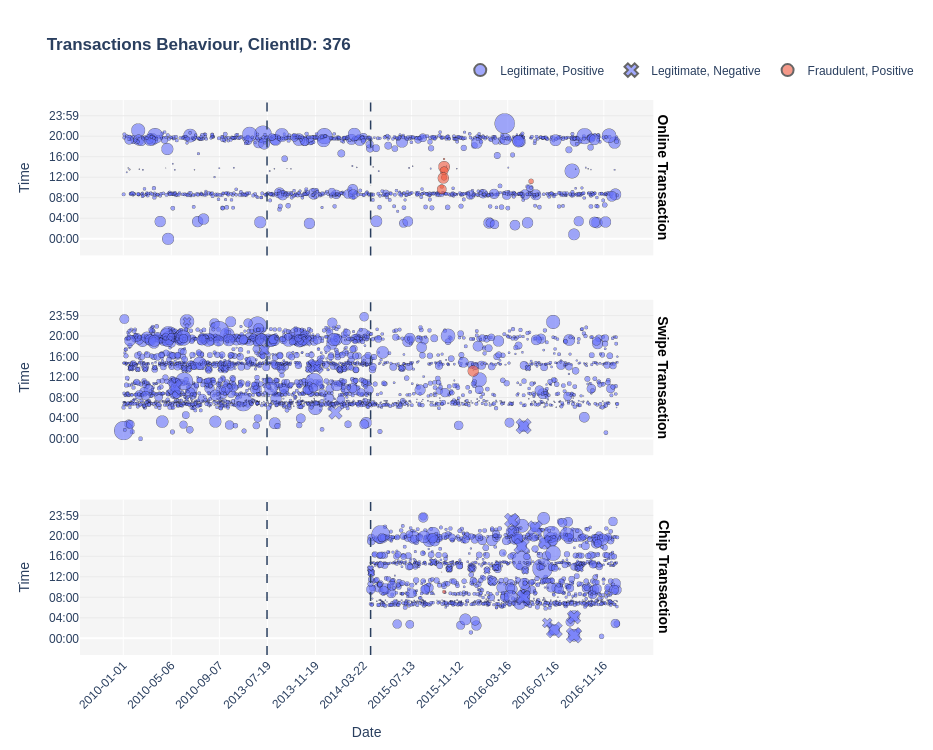

In [48]:
plot_client_behaviour_time(fraudulent_client_list[0])

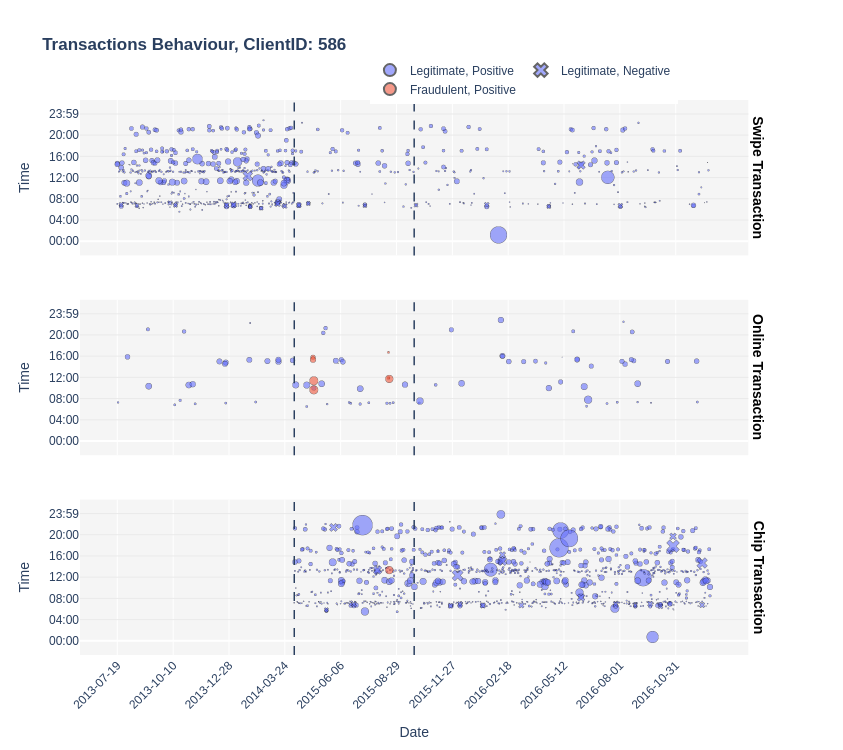

In [49]:
plot_client_behaviour_time(fraudulent_client_list[1])

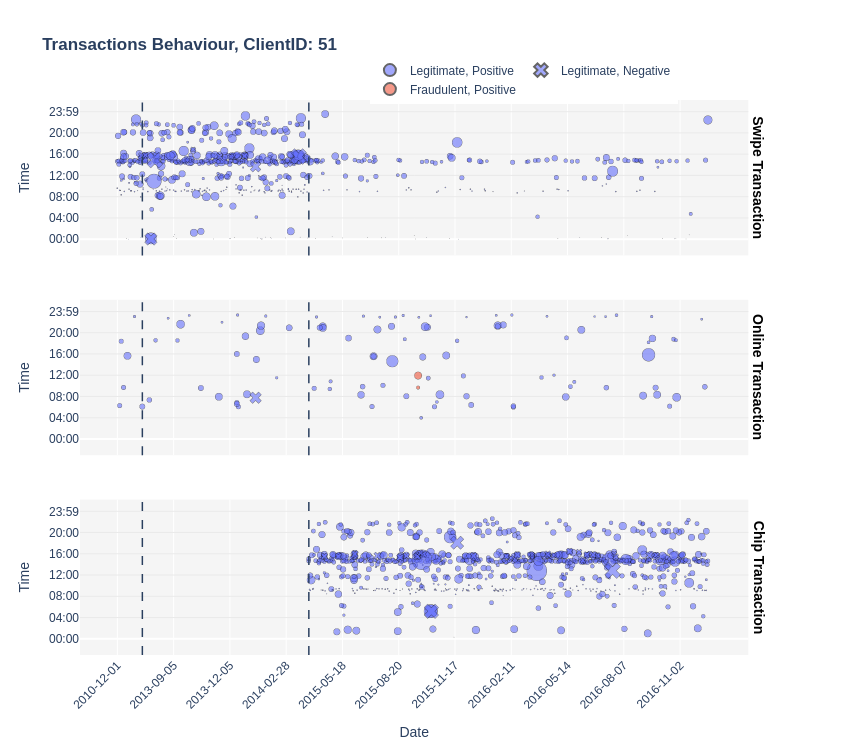

In [50]:
plot_client_behaviour_time(fraudulent_client_list[2])